# Arabic Question Answering with Neural and Transformer Models

This notebook develops and compares multiple approaches for Arabic question answering using the AAFAQ dataset.

The experiments include:
- Sequence-to-sequence RNN, GRU, and LSTM models
- TF-IDF, AraVec CBOW, and AraBERT text representations
- mT5
- AraGPT2
- Qwen2.5-1.5B-Instruct with LoRA fine-tuning

The models are evaluated using BLEU, while COMET evaluation is provided separately in the COMET evaluation notebook.

## 1. Setup and Imports

In [ ]:
!pip install transformers gensim tensorflow

In [2]:
!pip install -q transformers datasets evaluate sacrebleu sentencepiece accelerate

In [3]:
!pip install -q transformers accelerate bitsandbytes datasets peft

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC
from gensim.models import Word2Vec
import torch
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer
from transformers import BertTokenizer, BertModel
from datasets import Dataset
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense, Dropout, GRU, Input, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import evaluate
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from transformers import Trainer, TrainingArguments, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM

## 2. Dataset Loading and Preparation

In [6]:
df = pd.read_csv('/content/AAFAQ_preprocessed.csv')

In [7]:
df.head()

,QuestionText,Clean_Question,Category,Answer,Clean_Answer,question_tokens_split,answer_tokens_split,question_stemmed_snowball,answer_stemmed_snowball,question_lemma_qalsadi,answer_lemma_qalsadi,Lemmatized_Question,Lemmatized_Answer,Stemmed_Question,Stemmed_Answer
0,أيهما أفضل الدراسة في السابق أم في الوقت الحالي؟,ايهما افضل الدراسه السابق ام الوقت الحالي,التعليم,الدراسة في الوقت الحالي تعتبر أفضل بسبب توفر ا...,الدراسه الوقت الحالي تعتبر افضل بسبب توفر التك...,"['ايهما', 'افضل', 'الدراسه', 'السابق', 'ام', '...","['الدراسه', 'الوقت', 'الحالي', 'تعتبر', 'افضل'...","['ايهم', 'افضل', 'دراسه', 'سابق', 'ام', 'الو',...","['دراسه', 'الو', 'حال', 'تعتبر', 'افضل', 'سبب'...","['وهم', 'فضل', 'الدراسه', 'سابق', 'ام', 'وقت',...","['الدراسه', 'وقت', 'حال', 'اعتبر', 'فضل', 'سبب...",وهم فضل الدراسه سابق ام وقت حال,الدراسه وقت حال اعتبر فضل سبب توفر تكنولوجي ما...,ايهم افضل دراسه سابق ام الو حال,دراسه الو حال تعتبر افضل سبب توفر تكنولوج موار...
1,أليس القطن عماد الثروة في مصر؟,اليس القطن عماد الثروه مصر,الاقتصاد والعمل,القطن يعتبر من أهم المنتجات الزراعية في مصر، و...,القطن يعتبر اهم المنتجات الزراعيه مصر ويعد الا...,"['اليس', 'القطن', 'عماد', 'الثروه', 'مصر']","['القطن', 'يعتبر', 'اهم', 'المنتجات', 'الزراعي...","['اليس', 'قطن', 'عماد', 'ثروه', 'مصر']","['قطن', 'يعتبر', 'اهم', 'منتج', 'زراعيه', 'مصر...","['ليس', 'قطن', 'عماد', 'الثروه', 'مصر']","['قطن', 'اعتبر', 'اهم', 'منتج', 'الزراعيه', 'م...",ليس قطن عماد الثروه مصر,قطن اعتبر اهم منتج الزراعيه مصر أعاد الاعمده ا...,اليس قطن عماد ثروه مصر,قطن يعتبر اهم منتج زراعيه مصر يعد اعمده رييسيه...
2,أتصعد الشمس من الشرق؟,اتصعد الشمس الشرق,التعليم,الشمس تصعد من الشرق.,الشمس تصعد الشرق,"['اتصعد', 'الشمس', 'الشرق']","['الشمس', 'تصعد', 'الشرق']","['اتصعد', 'شمس', 'شرق']","['شمس', 'تصعد', 'شرق']","['اتصعد', 'شمس', 'شارق']","['شمس', 'صعد', 'شارق']",اتصعد شمس شارق,شمس صعد شارق,اتصعد شمس شرق,شمس تصعد شرق
3,أتعرف البكتيريا بأنها كائنات حية دقيقة؟,اتعرف البكتيريا بانها كاينات حيه دقيقه,التعليم,البكتيريا تُعرف بأنها كائنات حية دقيقة.,البكتيريا تعرف بانها كاينات حيه دقيقه,"['اتعرف', 'البكتيريا', 'بانها', 'كاينات', 'حيه...","['البكتيريا', 'تعرف', 'بانها', 'كاينات', 'حيه'...","['اتعرف', 'بكتير', 'بان', 'كاين', 'حيه', 'دقيق']","['بكتير', 'تعرف', 'بان', 'كاين', 'حيه', 'دقيق']","['اتعرف', 'بكتيريا', 'بان', 'كاينات', 'حي', 'د...","['بكتيريا', 'تعرف', 'بان', 'كاينات', 'حي', 'دق...",اتعرف بكتيريا بان كاينات حي دقيق,بكتيريا تعرف بان كاينات حي دقيق,اتعرف بكتير بان كاين حيه دقيق,بكتير تعرف بان كاين حيه دقيق
4,أيتكون الهواء أساساً من النيتروجين؟,ايتكون الهواء اساسا النيتروجين,التعليم,الهواء يتكون أساساً من النيتروجين.,الهواء يتكون اساسا النيتروجين,"['ايتكون', 'الهواء', 'اساسا', 'النيتروجين']","['الهواء', 'يتكون', 'اساسا', 'النيتروجين']","['ايتك', 'هواء', 'اساس', 'نيتروج']","['هواء', 'يتكو', 'اساس', 'نيتروج']","['ايتكون', 'هواء', 'اساسا', 'نيتروجين']","['هواء', 'تك', 'اساسا', 'نيتروجين']",ايتكون هواء اساسا نيتروجين,هواء تك اساسا نيتروجين,ايتك هواء اساس نيتروج,هواء يتكو اساس نيتروج


In [8]:
X =  df['Lemmatized_Question']
y = df['Answer'].apply(lambda x: 'start ' + str(x) + ' end')

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (4007,)
Testing data: (1002,)


## 3. Sequence Preparation

In [10]:
target_tokenizer = Tokenizer()
target_tokenizer.fit_on_texts(y_train)

y_train_seq = target_tokenizer.texts_to_sequences(y_train)
y_test_seq = target_tokenizer.texts_to_sequences(y_test)

In [11]:
max_decoder_len = 50

y_train_pad = pad_sequences(y_train_seq, maxlen=max_decoder_len, padding='post', truncating='post')
y_test_pad = pad_sequences(y_test_seq, maxlen=max_decoder_len, padding='post', truncating='post')


In [12]:
decoder_input_train = y_train_pad[:, :-1]
decoder_target_train = y_train_pad[:, 1:]

decoder_input_test = y_test_pad[:, :-1]
decoder_target_test = y_test_pad[:, 1:]

In [13]:
decoder_target_train = decoder_target_train.reshape(
    decoder_target_train.shape[0],
    decoder_target_train.shape[1],
    1)
decoder_target_test = decoder_target_test.reshape(
    decoder_target_test.shape[0],
    decoder_target_test.shape[1],
    1)

In [14]:
decoder_vocab_size = len(target_tokenizer.word_index) + 1

print("Decoder vocab size:", decoder_vocab_size)
print("Decoder input shape:", decoder_input_train.shape)
print("Decoder target shape:", decoder_target_train.shape)

Decoder vocab size: 14431
Decoder input shape: (4007, 49)
Decoder target shape: (4007, 49, 1)


## 4. Word Representations

### 4.1 TF-IDF

In [15]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

In [16]:
X_train_tfidf_seq = X_train_tfidf.reshape(X_train_tfidf.shape[0], X_train_tfidf.shape[1], 1)

X_test_tfidf_seq = X_test_tfidf.reshape(X_test_tfidf.shape[0], X_test_tfidf.shape[1], 1)

print("TF-IDF shape:", X_train_tfidf_seq.shape)


TF-IDF shape: (4007, 3654, 1)


### 4.2 AraVec CBOW

In [17]:
!wget "https://archive.org/download/aravec2.0/tweet_cbow_100.zip"

!unzip "tweet_cbow_100.zip"

--2026-06-05 19:08:05--  https://archive.org/download/aravec2.0/tweet_cbow_100.zip
Resolving archive.org (archive.org)... 207.241.224.2
Connecting to archive.org (archive.org)|207.241.224.2|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://dn710903.ca.archive.org/0/items/aravec2.0/tweet_cbow_100.zip [following]
--2026-06-05 19:08:06--  https://dn710903.ca.archive.org/0/items/aravec2.0/tweet_cbow_100.zip
Resolving dn710903.ca.archive.org (dn710903.ca.archive.org)... 204.62.248.114
Connecting to dn710903.ca.archive.org (dn710903.ca.archive.org)|204.62.248.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 253946430 (242M) [application/zip]
Saving to: ‘tweet_cbow_100.zip’

tweet_cbow_100.zip  100%[===================>] 242.18M  2.37MB/s    in 78s     

2026-06-05 19:09:25 (3.09 MB/s) - ‘tweet_cbow_100.zip’ saved [253946430/253946430]

Archive:  tweet_cbow_100.zip
  inflating: tweets_cbow_100         
  inflating: tweets_cbow_

In [18]:
aravec_model = Word2Vec.load("tweets_cbow_100")

wv = aravec_model.wv

In [19]:
max_encoder_len = 30
embedding_dim = 100

In [20]:
def cbow_sequence(sentence):
  tokens = str(sentence).split()
  sequences = []

  for word in tokens[:max_encoder_len]:
    if word in wv:
      sequences.append(wv[word])

    else:
      sequences.append(np.zeros(embedding_dim))

  while len(sequences) < max_encoder_len:
    sequences.append(np.zeros(embedding_dim))

  return np.array(sequences)

In [21]:
X_train_cbow_seq = np.array([cbow_sequence(sentence) for sentence in X_train])
X_test_cbow_seq = np.array([cbow_sequence(sentence) for sentence in X_test])

print("CBOW shape:", X_train_cbow_seq.shape)

CBOW shape: (4007, 30, 100)


### 4.3 AraBERT

In [22]:
bert_tokenizer = AutoTokenizer.from_pretrained("aubmindlab/bert-base-arabertv02")
bert_model = AutoModel.from_pretrained("aubmindlab/bert-base-arabertv02")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/825k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.64M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bert_model = bert_model.to(device)

In [24]:
def get_bert_sequence_embeddings(texts, batch_size=16):

  all_embeddings = []
  for i in range(0, len(texts), batch_size):

    batch_texts = texts.iloc[i:i+batch_size].tolist()

    inputs = bert_tokenizer(
      batch_texts,
      return_tensors="pt",
      padding='max_length',
      truncation=True,
      max_length=64
      )

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
      outputs = bert_model(**inputs)

    batch_embeddings = outputs.last_hidden_state.cpu().numpy()
    all_embeddings.append(batch_embeddings)

  embeddings = np.concatenate(all_embeddings, axis=0)

  return embeddings

In [25]:
X_train_bert_seq = get_bert_sequence_embeddings(X_train)
X_test_bert_seq = get_bert_sequence_embeddings(X_test)

print("BERT shape:", X_train_bert_seq.shape)

BERT shape: (4007, 64, 768)


## 5. Sequence-to-Sequence Models

In [26]:
def build_model(encoder_shape, cell_type='RNN'):
  encoder_inputs = Input(shape=encoder_shape)

  if cell_type == 'RNN':
    _, encoder_state = SimpleRNN(128, return_state=True)(encoder_inputs)
    encoder_states = encoder_state

  elif cell_type == 'GRU':
    _, encoder_state = GRU(128, return_state=True)(encoder_inputs)
    encoder_states = encoder_state

  else:
    _, state_h, state_c = LSTM(128, return_state=True)(encoder_inputs)
    encoder_states = [state_h, state_c]

  decoder_inputs = Input(shape=(max_decoder_len - 1,))

  decoder_embedding = Embedding(
      input_dim=decoder_vocab_size,
      output_dim=128,
      mask_zero=True
  )(decoder_inputs)

  if cell_type == 'RNN':
    decoder_outputs = SimpleRNN(128, return_sequences=True)(
        decoder_embedding,
        initial_state=encoder_states
    )

  elif cell_type == 'GRU':
    decoder_outputs = GRU(128, return_sequences=True)(
        decoder_embedding,
        initial_state=encoder_states
    )

  else:
    decoder_outputs = LSTM(128, return_sequences=True)(
        decoder_embedding,
        initial_state=encoder_states
    )

  decoder_outputs = Dense(decoder_vocab_size, activation='softmax')(decoder_outputs)

  model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

  model.compile(
      optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )

  return model

**Bleu Evaluation**

In [27]:
def decode_sequence(model, encoder_seq):

  target_seq = np.zeros((1, max_decoder_len - 1))
  target_seq[0, 0] = target_tokenizer.word_index['start']

  decoded = ''

  for i in range(max_decoder_len - 2):

    output_tokens = model.predict([encoder_seq, target_seq], verbose=0)

    sampled_index = np.argmax(output_tokens[0, i, :])

    word = target_tokenizer.index_word.get(sampled_index, '')

    if word == 'end' or word == '':
      break

    if word != 'start':
      decoded += ' ' + word

    target_seq[0, i + 1] = sampled_index

  return decoded.strip()


In [28]:
def evaluate_bleu(model, X_test_representation, model_name, file_name):

  predictions = []

  n = min(100, len(X_test_representation))

  for i in range(n):

    seq = X_test_representation[i].reshape(
        1,
        X_test_representation.shape[1],
        X_test_representation.shape[2])

    pred = decode_sequence(model, seq)

    predictions.append(pred)

  references = [str(text).replace('start', '').replace('end', '').strip() for text in y_test.iloc[:n]]
  predictions = [str(text).strip() for text in predictions]

  sources = [str(text) for text in X_test.iloc[:n]]

  smooth = SmoothingFunction().method1

  references_tok = [[r.split()] for r in references]
  predictions_tok = [p.split() for p in predictions]

  bleu_score = corpus_bleu(references_tok, predictions_tok, smoothing_function=smooth)

  comet_df = pd.DataFrame({
      'Model': model_name,
      'src': sources,
      'mt': predictions,
      'ref': references
  })

  comet_df.to_csv(file_name, index=False, encoding='utf-8-sig')

  print(model_name)
  print("BLEU Score:", bleu_score)

  return bleu_score

### 5.1 RNN

### **RNN + TF-IDF**

In [29]:
rnn_tfidf = build_model(
    encoder_shape=(X_train_tfidf_seq.shape[1], X_train_tfidf_seq.shape[2]), cell_type='RNN')

rnn_tfidf.fit(
    [X_train_tfidf_seq, decoder_input_train],
    decoder_target_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

rnn_tfidf_bleu = evaluate_bleu(
    rnn_tfidf, X_test_tfidf_seq, 'RNN + TF-IDF', 'rnn_tfidf_comet.csv')

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 287ms/step - accuracy: 0.0543 - loss: 8.5886 - val_accuracy: 0.0541 - val_loss: 8.0675
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 224ms/step - accuracy: 0.0921 - loss: 7.7069 - val_accuracy: 0.1106 - val_loss: 7.9298
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 225ms/step - accuracy: 0.1112 - loss: 7.5068 - val_accuracy: 0.1135 - val_loss: 7.7918
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 226ms/step - accuracy: 0.1180 - loss: 7.2907 - val_accuracy: 0.1236 - val_loss: 7.6494
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 12s 226ms/step - accuracy: 0.1266 - loss: 7.0518 - val_accuracy: 0.1302 - val_loss: 7.5638
RNN + TF-IDF
BLEU Score: 0.00022467739515909078


### **RNN + AraVec CBOW**

In [30]:
rnn_cbow = build_model(
    encoder_shape=(X_train_cbow_seq.shape[1], X_train_cbow_seq.shape[2]), cell_type='RNN')

rnn_cbow.fit(
    [X_train_cbow_seq, decoder_input_train],
    decoder_target_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

rnn_cbow_bleu = evaluate_bleu(
    rnn_cbow, X_test_cbow_seq, 'RNN + AraVec CBOW', 'rnn_cbow_comet.csv')

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - accuracy: 0.0824 - loss: 8.6387 - val_accuracy: 0.0539 - val_loss: 8.0498
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.1002 - loss: 7.7137 - val_accuracy: 0.1100 - val_loss: 7.9155
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.1094 - loss: 7.5104 - val_accuracy: 0.1127 - val_loss: 7.7787
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.1189 - loss: 7.2960 - val_accuracy: 0.1242 - val_loss: 7.5914
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.1273 - loss: 7.0461 - val_accuracy: 0.1307 - val_loss: 7.5442
RNN + AraVec CBOW
BLEU Score: 0.00022467739515909078


### **RNN + AraBERT**

In [31]:
rnn_bert = build_model(
    encoder_shape=(X_train_bert_seq.shape[1], X_train_bert_seq.shape[2]), cell_type='RNN')

rnn_bert.fit(
    [X_train_bert_seq, decoder_input_train],
    decoder_target_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

rnn_bert_bleu = evaluate_bleu(
    rnn_bert, X_test_bert_seq, 'RNN + AraBERT', 'rnn_bert_comet.csv')

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 9s 106ms/step - accuracy: 0.0511 - loss: 8.5253 - val_accuracy: 0.1081 - val_loss: 8.0471
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.1085 - loss: 7.6648 - val_accuracy: 0.1106 - val_loss: 7.8734
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.1132 - loss: 7.4409 - val_accuracy: 0.1201 - val_loss: 7.7018
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.1206 - loss: 7.2329 - val_accuracy: 0.1225 - val_loss: 7.6726
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.1255 - loss: 7.0549 - val_accuracy: 0.1297 - val_loss: 7.5880
RNN + AraBERT
BLEU Score: 0.00025493583987234785


### **RNN Comparison**

In [32]:
rnn_results = pd.DataFrame({
    'Representation': ['TF-IDF', 'AraVec CBOW', 'AraBERT'],
    'BLEU Score': [rnn_tfidf_bleu, rnn_cbow_bleu, rnn_bert_bleu],
})

rnn_results

,Representation,BLEU Score
0,TF-IDF,0.000225
1,AraVec CBOW,0.000225
2,AraBERT,0.000255


### 5.2 GRU

### **GRU + TF-IDF**

In [33]:
gru_tfidf = build_model(
    encoder_shape=(X_train_tfidf_seq.shape[1], X_train_tfidf_seq.shape[2]), cell_type='GRU')

gru_tfidf.fit(
    [X_train_tfidf_seq, decoder_input_train],
    decoder_target_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

gru_tfidf_bleu = evaluate_bleu(
    gru_tfidf, X_test_tfidf_seq, 'GRU + TF-IDF', 'gru_tfidf_comet.csv')

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 226ms/step - accuracy: 0.0757 - loss: 8.7361 - val_accuracy: 0.0541 - val_loss: 8.0961
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - accuracy: 0.0935 - loss: 7.7351 - val_accuracy: 0.1196 - val_loss: 7.9825
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 206ms/step - accuracy: 0.1211 - loss: 7.4828 - val_accuracy: 0.1252 - val_loss: 7.8411
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - accuracy: 0.1232 - loss: 7.2597 - val_accuracy: 0.1256 - val_loss: 7.6878
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - accuracy: 0.1266 - loss: 7.0323 - val_accuracy: 0.1277 - val_loss: 7.5653
GRU + TF-IDF
BLEU Score: 9.47473788481614e-05


### **GRU + AraVec CBOW**

In [34]:
gru_cbow = build_model(
    encoder_shape=(X_train_cbow_seq.shape[1], X_train_cbow_seq.shape[2]), cell_type='GRU')

gru_cbow.fit(
    [X_train_cbow_seq, decoder_input_train],
    decoder_target_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

gru_cbow_bleu = evaluate_bleu(
    gru_cbow, X_test_cbow_seq, 'GRU + AraVec CBOW', 'gru_cbow_comet.csv')

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 93ms/step - accuracy: 0.0749 - loss: 8.7566 - val_accuracy: 0.0541 - val_loss: 8.1153
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.0939 - loss: 7.7387 - val_accuracy: 0.1197 - val_loss: 7.9717
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.1217 - loss: 7.4816 - val_accuracy: 0.1254 - val_loss: 7.8440
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.1236 - loss: 7.2498 - val_accuracy: 0.1254 - val_loss: 7.6748
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.1271 - loss: 7.0185 - val_accuracy: 0.1273 - val_loss: 7.5729
GRU + AraVec CBOW
BLEU Score: 0.00024731719199772744


### **GRU + AraBERT**

In [35]:
gru_bert = build_model(
    encoder_shape=(X_train_bert_seq.shape[1], X_train_bert_seq.shape[2]), cell_type='GRU')

gru_bert.fit(
    [X_train_bert_seq, decoder_input_train],
    decoder_target_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

gru_bert_bleu = evaluate_bleu(
    gru_bert, X_test_bert_seq, 'GRU + AraBERT', 'gru_bert_comet.csv')

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.0495 - loss: 8.5903 - val_accuracy: 0.0773 - val_loss: 8.0412
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.0936 - loss: 7.7105 - val_accuracy: 0.1188 - val_loss: 7.9649
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.1205 - loss: 7.5037 - val_accuracy: 0.1239 - val_loss: 7.8150
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.1235 - loss: 7.3111 - val_accuracy: 0.1280 - val_loss: 7.6752
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.1316 - loss: 7.0584 - val_accuracy: 0.1335 - val_loss: 7.5418
GRU + AraBERT
BLEU Score: 0.0007199213082362788


### **GRU Comparison**

In [36]:
gru_results = pd.DataFrame({
    'Representation': ['TF-IDF', 'AraVec CBOW', 'AraBERT'],
    'BLEU Score': [gru_tfidf_bleu, gru_cbow_bleu, gru_bert_bleu],
})

gru_results

,Representation,BLEU Score
0,TF-IDF,0.000095
1,AraVec CBOW,0.000247
2,AraBERT,0.000720


### 5.3 LSTM

### **LSTM + TF-IDF**

In [37]:
lstm_tfidf = build_model(
    encoder_shape=(X_train_tfidf_seq.shape[1], X_train_tfidf_seq.shape[2]), cell_type='LSTM')

lstm_tfidf.fit(
    [X_train_tfidf_seq, decoder_input_train],
    decoder_target_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

lstm_tfidf_bleu = evaluate_bleu(
    lstm_tfidf, X_test_tfidf_seq, 'LSTM + TF-IDF', 'lstm_tfidf_comet.csv')

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 219ms/step - accuracy: 0.0622 - loss: 8.6849 - val_accuracy: 0.0541 - val_loss: 8.0214
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 218ms/step - accuracy: 0.0667 - loss: 7.6750 - val_accuracy: 0.0717 - val_loss: 7.8320
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.1017 - loss: 7.4003 - val_accuracy: 0.1203 - val_loss: 7.7104
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.1202 - loss: 7.2203 - val_accuracy: 0.1241 - val_loss: 7.6672
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 11s 208ms/step - accuracy: 0.1220 - loss: 7.0963 - val_accuracy: 0.1241 - val_loss: 7.6509
LSTM + TF-IDF
BLEU Score: 0.0002603260561708226


### **LSTM + AraVec CBOW**

In [38]:
lstm_cbow = build_model(
    encoder_shape=(X_train_cbow_seq.shape[1], X_train_cbow_seq.shape[2]), cell_type='LSTM')

lstm_cbow.fit(
    [X_train_cbow_seq, decoder_input_train],
    decoder_target_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

lstm_cbow_bleu = evaluate_bleu(
    lstm_cbow, X_test_cbow_seq, 'LSTM + AraVec CBOW', 'lstm_cbow_comet.csv')

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 94ms/step - accuracy: 0.0624 - loss: 8.7052 - val_accuracy: 0.0601 - val_loss: 8.0609
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.0591 - loss: 7.6880 - val_accuracy: 0.0666 - val_loss: 7.8367
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.1007 - loss: 7.4068 - val_accuracy: 0.1186 - val_loss: 7.7059
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.1202 - loss: 7.2239 - val_accuracy: 0.1240 - val_loss: 7.6629
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.1228 - loss: 7.0959 - val_accuracy: 0.1243 - val_loss: 7.6432
LSTM + AraVec CBOW
BLEU Score: 0.0002584050076328846


### **LSTM + AraBERT**

In [39]:
lstm_bert = build_model(
    encoder_shape=(X_train_bert_seq.shape[1], X_train_bert_seq.shape[2]), cell_type='LSTM')

lstm_bert.fit(
    [X_train_bert_seq, decoder_input_train],
    decoder_target_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

lstm_bert_bleu = evaluate_bleu(
    lstm_bert, X_test_bert_seq, 'LSTM + AraBERT', 'lstm_bert_comet.csv')

Epoch 1/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - accuracy: 0.0391 - loss: 8.5256 - val_accuracy: 0.0638 - val_loss: 8.0410
Epoch 2/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.0573 - loss: 7.6665 - val_accuracy: 0.0554 - val_loss: 7.8565
Epoch 3/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.0892 - loss: 7.4454 - val_accuracy: 0.1136 - val_loss: 7.7494
Epoch 4/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.1164 - loss: 7.2787 - val_accuracy: 0.1199 - val_loss: 7.7037
Epoch 5/5
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.1208 - loss: 7.1479 - val_accuracy: 0.1258 - val_loss: 7.6719
LSTM + AraBERT
BLEU Score: 0.0002092530065039145


### **LSTM Comparison**

In [40]:
lstm_results = pd.DataFrame({
    'Representation': ['TF-IDF', 'AraVec CBOW', 'AraBERT'],
    'BLEU Score': [lstm_tfidf_bleu, lstm_cbow_bleu, lstm_bert_bleu],
})

lstm_results

,Representation,BLEU Score
0,TF-IDF,0.000260
1,AraVec CBOW,0.000258
2,AraBERT,0.000209


### 5.4 Seq2Seq Final Comparison

In [41]:
rnn_results['Model'] = 'RNN'
gru_results['Model'] = 'GRU'
lstm_results['Model'] = 'LSTM'

seq2seq_results = pd.concat([rnn_results, gru_results, lstm_results], ignore_index=True)

seq2seq_results = seq2seq_results[['Model', 'Representation', 'BLEU Score']]

seq2seq_results


,Model,Representation,BLEU Score
0,RNN,TF-IDF,0.000225
1,RNN,AraVec CBOW,0.000225
2,RNN,AraBERT,0.000255
3,GRU,TF-IDF,0.000095
4,GRU,AraVec CBOW,0.000247
5,GRU,AraBERT,0.000720
6,LSTM,TF-IDF,0.000260
7,LSTM,AraVec CBOW,0.000258
8,LSTM,AraBERT,0.000209


## 6. Transformer Models

### 6.1 mT5

In [42]:
dataset = Dataset.from_pandas(df)

dataset = dataset.train_test_split(test_size=0.2, seed=42)

train_data = dataset['train']
test_data = dataset['test']

val_test = test_data.train_test_split(test_size=0.5, seed=42)

test_data = val_test['test']
val_data = val_test['train']

print(train_data)
print(val_data)
print(test_data)

Dataset({
    features: ['QuestionText', 'Clean_Question', 'Category', 'Answer', 'Clean_Answer', 'question_tokens_split', 'answer_tokens_split', 'question_stemmed_snowball', 'answer_stemmed_snowball', 'question_lemma_qalsadi', 'answer_lemma_qalsadi', 'Lemmatized_Question', 'Lemmatized_Answer', 'Stemmed_Question', 'Stemmed_Answer'],
    num_rows: 4007
})
Dataset({
    features: ['QuestionText', 'Clean_Question', 'Category', 'Answer', 'Clean_Answer', 'question_tokens_split', 'answer_tokens_split', 'question_stemmed_snowball', 'answer_stemmed_snowball', 'question_lemma_qalsadi', 'answer_lemma_qalsadi', 'Lemmatized_Question', 'Lemmatized_Answer', 'Stemmed_Question', 'Stemmed_Answer'],
    num_rows: 501
})
Dataset({
    features: ['QuestionText', 'Clean_Question', 'Category', 'Answer', 'Clean_Answer', 'question_tokens_split', 'answer_tokens_split', 'question_stemmed_snowball', 'answer_stemmed_snowball', 'question_lemma_qalsadi', 'answer_lemma_qalsadi', 'Lemmatized_Question', 'Lemmatized_Ans

In [43]:
model_name = "google/mt5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [59]:
def preprocess_data(examples):

  questions = ['answer question: ' + question for question in examples['QuestionText']]

  answers = [answer for answer in examples['Answer']]

  inputs = tokenizer(questions, truncation=True, max_length=64)

  labels = tokenizer(answers, truncation=True, max_length=64)

  inputs['labels'] = labels['input_ids']

  return inputs


In [60]:
tokenized_train = train_data.map(preprocess_data, batched=True)
tokenized_val = val_data.map(preprocess_data, batched=True)
tokenized_test = test_data.map(preprocess_data, batched=True)

print(tokenized_train[0])

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/501 [00:00<?, ? examples/s]

Map:   0%|          | 0/501 [00:00<?, ? examples/s]

{'QuestionText': 'كيف تؤثر ضربة الشمس على القلب؟', 'Clean_Question': 'توثر ضربه الشمس علي القلب', 'Category': 'الصحة', 'Answer': 'تؤثر ضربة الشمس على القلب من خلال زيادة معدل ضربات القلب، وانخفاض ضغط الدم، والإجهاد الحراري الذي يمكن أن يؤدي إلى تلف القلب والأوعية الدموية.', 'Clean_Answer': 'توثر ضربه الشمس علي القلب خلال زياده معدل ضربات القلب وانخفاض ضغط الدم والاجهاد الحراري يمكن ان يودي الي تلف القلب والاوعيه الدمويه', 'question_tokens_split': "['توثر', 'ضربه', 'الشمس', 'علي', 'القلب']", 'answer_tokens_split': "['توثر', 'ضربه', 'الشمس', 'علي', 'القلب', 'خلال', 'زياده', 'معدل', 'ضربات', 'القلب', 'وانخفاض', 'ضغط', 'الدم', 'والاجهاد', 'الحراري', 'يمكن', 'ان', 'يودي', 'الي', 'تلف', 'القلب', 'والاوعيه', 'الدمويه']", 'question_stemmed_snowball': "['توثر', 'ضرب', 'شمس', 'عل', 'قلب']", 'answer_stemmed_snowball': "['توثر', 'ضرب', 'شمس', 'عل', 'قلب', 'خلال', 'زياد', 'معدل', 'ضرب', 'قلب', 'وانخفاض', 'ضغط', 'الدم', 'اجهاد', 'حرار', 'يمك', 'ان', 'يود', 'ال', 'تلف', 'قلب', 'اوع', 'دمويه']", 'ques

In [61]:
data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=model)

In [62]:
training_args = Seq2SeqTrainingArguments(
    output_dir="./mt5_question_answering",
    learning_rate=5e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=3,
    predict_with_generate=True,
    eval_strategy="epoch")

In [63]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,
    data_collator=data_collator)

In [64]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,3.634925,2.514186
2,3.220499,2.357563
3,3.067033,2.307829


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=6012, training_loss=3.9052200019161303, metrics={'train_runtime': 1032.4147, 'train_samples_per_second': 11.644, 'train_steps_per_second': 5.823, 'total_flos': 264185858734080.0, 'train_loss': 3.9052200019161303, 'epoch': 3.0})

In [65]:
def generate_answer_t5(question):

  input_text = 'answer question: ' + question

  inputs = tokenizer(
      input_text,
      return_tensors='pt',
      truncation=True,
      max_length=128
  ).to(model.device)

  outputs = model.generate(
      **inputs,
      max_length=128,
      num_beams=4
  )

  answer = tokenizer.decode(outputs[0], skip_special_tokens=True)

  return answer


In [66]:
print("T5 Question Answering Results")

for i in range(5):

  question = test_data[i]['QuestionText']
  real_answer = test_data[i]['Answer']
  generated_answer = generate_answer_t5(question)

  print("Question:", question)
  print("Answer:", real_answer)
  print("Predicted Answer:", generated_answer)

T5 Question Answering Results
Question: أين يقع المحيط الهندي؟
Answer: المحيط الهندي يقع بين إفريقيا وآسيا وأستراليا.
Predicted Answer: أين يقع المحيط الهندي في الهند.
Question: لماذا تُحبُّ القراءة؟
Answer: الإجابة تعتمد على الأسباب الشخصية التي تجعل الفرد يحب القراءة.
Predicted Answer: تُحب القراءة من خلال تحسين الفهم، وتحسين الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم، وتعزيز الفهم
Question: بمَ يُقاس التيار الكهربائي؟
Answer: يُقاس التيار الكهربائي باستخدام جهاز الأميتر.
Predicted Answer: التيار الكهربائي يُقاس التيار الكهربائي لأنه يُقاس التيار الكهربائي لأنه يُقاس التيار الكهربائي لأنه يُقاس التيار الكهربائي يُقاس التيار الكهربائي.
Question: متى تم إطلاق أول قمر صناعي؟
Answer: تم إطلاق أول قمر صناعي، سبوتنيك 1، في 4 أكتوبر 1957.

In [67]:
bleu = evaluate.load("sacrebleu")

predictions = []
references = []

for example in test_data.select(range(100)):

  question = example['QuestionText']
  answer = example['Answer']
  prediction = generate_answer_t5(question)

  predictions.append(prediction)
  references.append([answer])

result = bleu.compute(predictions=predictions, references=references)

t5_bleu = result['score']

print('T5 BLEU Score: ', t5_bleu)

T5 BLEU Score:  16.06771641582648


In [68]:
t5_sources = [
    test_data[i]['QuestionText']
    for i in range(len(predictions))
]

t5_references_clean = [
    references[i][0]
    for i in range(len(references))
]

t5_comet_df = pd.DataFrame({
    'Model': 'T5',
    'src': t5_sources,
    'mt': predictions,
    'ref': t5_references_clean
})

t5_comet_df.to_csv('t5_comet.csv', index=False, encoding='utf-8-sig')

In [69]:
t5_results = pd.DataFrame({
    'Model': ['T5'],
    'BLEU Score': [t5_bleu],
})

t5_results

,Model,BLEU Score
0,T5,16.067716


### 6.2 Qwen2.5

In [70]:
qwen_model_name = "Qwen/Qwen2.5-1.5B-Instruct"

qwen_tokenizer = AutoTokenizer.from_pretrained(qwen_model_name)
qwen_model = AutoModelForCausalLM.from_pretrained(qwen_model_name, device_map="auto")

qwen_tokenizer.pad_token = qwen_tokenizer.eos_token

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [71]:
def format_data(example):

  question = example['QuestionText']
  answer = example['Answer']

  text = f"Answer the Arabic question:\nQuestion: {question}\nAnswer: {answer}"

  return {'text': text}

In [72]:
train_qwen = train_data.map(format_data)
val_qwen = val_data.map(format_data)
test_qwen = test_data.map(format_data)

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/501 [00:00<?, ? examples/s]

Map:   0%|          | 0/501 [00:00<?, ? examples/s]

In [73]:
def tokenize_data(example):
  return qwen_tokenizer(
      example['text'],
      truncation=True,
      max_length=256)

In [74]:
train_qwen = train_qwen.map(tokenize_data, batched=True, remove_columns=train_qwen.column_names)
val_qwen = val_qwen.map(tokenize_data, batched=True, remove_columns=val_qwen.column_names)
test_qwen = test_qwen.map(tokenize_data, batched=True, remove_columns=test_qwen.column_names)

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/501 [00:00<?, ? examples/s]

Map:   0%|          | 0/501 [00:00<?, ? examples/s]

In [76]:
!pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 10.9 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [77]:
lora_config = LoraConfig(
    r=8,
    target_modules=["q_proj", "v_proj"],
    task_type="CAUSAL_LM"
)

qwen_model = get_peft_model(qwen_model, lora_config)

In [78]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=qwen_tokenizer,
    mlm=False
)

In [79]:
training_args = TrainingArguments(
    output_dir="./qwen_question_answering",
    learning_rate=2e-4,
    per_device_train_batch_size=1,
    num_train_epochs=2,
    eval_strategy="epoch",
)

In [80]:
trainer = Trainer(
    model=qwen_model,
    args=training_args,
    train_dataset=train_qwen,
    eval_dataset=val_qwen,
    data_collator=data_collator
)

In [81]:
trainer.train()

Epoch,Training Loss,Validation Loss
1,1.130596,1.115471
2,1.003579,1.088941


TrainOutput(global_step=8014, training_loss=1.0968415836517966, metrics={'train_runtime': 2877.1707, 'train_samples_per_second': 2.785, 'train_steps_per_second': 2.785, 'total_flos': 4020608764078080.0, 'train_loss': 1.0968415836517966, 'epoch': 2.0})

In [82]:
def generate_answer_qwen(question):

    prompt = f"Answer the Arabic question:\nQuestion: {question}\nAnswer:"

    inputs = qwen_tokenizer(
        prompt,
        return_tensors="pt"
    ).to(qwen_model.device)

    outputs = qwen_model.generate(
        **inputs,
        max_new_tokens=80,
        do_sample=False,
        pad_token_id=qwen_tokenizer.eos_token_id
    )

    result = qwen_tokenizer.decode(outputs[0], skip_special_tokens=True)

    answer = result.split("Answer:")[-1].strip()

    return answer

In [83]:
print("Qwen Question Answering Results")

for i in range(5):

  question = test_data[i]['QuestionText']
  real_answer = test_data[i]['Answer']
  generated_answer = generate_answer_qwen(question)

  print("Question:", question)
  print("Answer:", real_answer)
  print("Predicted Answer:", generated_answer)

Qwen Question Answering Results
Question: أين يقع المحيط الهندي؟
Answer: المحيط الهندي يقع بين إفريقيا وآسيا وأستراليا.
Predicted Answer: المحيط الهندي يقع في شرق آسيا ويعبر عبر أوروبا وأفريقيا. يمتد من البحر الأبيض المتوسط إلى المحيط الأطلسي، ويغطي حوالي 70% من سطح الأرض. يمر عبر العديد من الدول والمناطق الحضرية مثل الهند، إندونيسيا، وتايل
Question: لماذا تُحبُّ القراءة؟
Answer: الإجابة تعتمد على الأسباب الشخصية التي تجعل الفرد يحب القراءة.
Predicted Answer: تُحبُّ القراءة لأنها توفر معلومات جديدة، وتعزز الذاكرة، وتزيد من التفكير النقدي، وتساعد في تنمية المهارات اللغوية والثقافية. كما أنها تتيح للإنسان التواصل مع الآخرين عبر الكتابة والقراءة.
Question: بمَ يُقاس التيار الكهربائي؟
Answer: يُقاس التيار الكهربائي باستخدام جهاز الأميتر.
Predicted Answer: يُقاس التيار الكهربائي باستخدام مقياس التيار الكهربائي مثل الميترات أو الكومبوستات.
Question: متى تم إطلاق أول قمر صناعي؟
Answer: تم إطلاق أول قمر صناعي، سبوتنيك 1، في 4 أكتوبر 1957.
Predicted Answer: تم إطلاق أول قمر صناعي في عام 1957 بو

In [84]:
bleu = evaluate.load("sacrebleu")

qwen_predictions = []
qwen_references = []

for example in test_data.select(range(100)):

  question = example['QuestionText']
  answer = example['Answer']
  prediction = generate_answer_qwen(question)

  qwen_predictions.append(prediction)
  qwen_references.append([answer])

qwen_result = bleu.compute(predictions=qwen_predictions, references=qwen_references)

qwen_bleu = qwen_result['score']

print('Qwen BLEU Score: ', qwen_bleu)

Qwen BLEU Score:  13.802488278391326


In [85]:
qwen_sources = [
    test_data[i]['QuestionText']
    for i in range(len(qwen_predictions))
]

qwen_references_clean = [
    qwen_references[i][0]
    for i in range(len(qwen_references))
]

qwen_comet_df = pd.DataFrame({
    'Model': 'Qwen',
    'src': qwen_sources,
    'mt': qwen_predictions,
    'ref': qwen_references_clean
})

qwen_comet_df.to_csv('qwen_comet.csv', index=False, encoding='utf-8-sig')

In [86]:
qwen_results = pd.DataFrame({
    'Model': ['Qwen'],
    'BLEU Score': [qwen_bleu],
})

qwen_results

,Model,BLEU Score
0,Qwen,13.802488


### 6.3 AraGPT2

In [87]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

In [88]:
gpt_model_name = "aubmindlab/aragpt2-base"

gpt_tokenizer = GPT2Tokenizer.from_pretrained(gpt_model_name)
gpt_model = GPT2LMHeadModel.from_pretrained(gpt_model_name)

gpt_tokenizer.pad_token = gpt_tokenizer.eos_token
gpt_model.config.pad_token_id = gpt_tokenizer.pad_token_id

vocab.json:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.50M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.52M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: aubmindlab/aragpt2-base
Key                         | Status     |  | 
----------------------------+------------+--+-
h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [89]:
def format_data_gpt(example):

  question = example['QuestionText']
  answer = example['Answer']

  text = f"Answer the Arabic question:\nQuestion: {question}\nAnswer: {answer}"

  return {'text': text}

In [90]:
train_gpt = train_data.map(format_data_gpt)
val_gpt = val_data.map(format_data_gpt)
test_gpt = test_data.map(format_data_gpt)

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/501 [00:00<?, ? examples/s]

Map:   0%|          | 0/501 [00:00<?, ? examples/s]

In [91]:
def tokenize_data_gpt(example):
  return gpt_tokenizer(
      example['text'],
      truncation=True,
      max_length=256)

In [92]:
train_gpt = train_gpt.map(tokenize_data_gpt, batched=True, remove_columns=train_gpt.column_names)
val_gpt = val_gpt.map(tokenize_data_gpt, batched=True, remove_columns=val_gpt.column_names)
test_gpt = test_gpt.map(tokenize_data_gpt, batched=True, remove_columns=test_gpt.column_names)

Map:   0%|          | 0/4007 [00:00<?, ? examples/s]

Map:   0%|          | 0/501 [00:00<?, ? examples/s]

Map:   0%|          | 0/501 [00:00<?, ? examples/s]

In [93]:
gpt_data_collator = DataCollatorForLanguageModeling(
    tokenizer=gpt_tokenizer,
    mlm=False
)

In [94]:
gpt_training_args = TrainingArguments(
    output_dir="./gpt_question_answering",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    optim="adamw_torch",
    eval_strategy="epoch"
    )

In [95]:
gpt_trainer = Trainer(
    model=gpt_model,
    args=gpt_training_args,
    train_dataset=train_gpt,
    eval_dataset=val_gpt,
    data_collator=gpt_data_collator
)

In [96]:
gpt_trainer.train()

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,2.768505,1.618787
2,1.901564,1.493864
3,1.746038,1.457542


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1503, training_loss=2.1381626776354516, metrics={'train_runtime': 410.7318, 'train_samples_per_second': 29.267, 'train_steps_per_second': 3.659, 'total_flos': 501626605824000.0, 'train_loss': 2.1381626776354516, 'epoch': 3.0})

In [97]:
def generate_answer_gpt(question):

  prompt = f"Answer the Arabic question:\nQuestion: {question}\nAnswer:"

  inputs = gpt_tokenizer(
      prompt,
      return_tensors="pt",
      truncation=True,
      max_length=128)

  inputs = {key: value.to(gpt_model.device) for key, value in inputs.items()}

  outputs = gpt_model.generate(
      **inputs,
      max_new_tokens=80,
      do_sample=False,
      pad_token_id=gpt_tokenizer.eos_token_id
  )

  result = gpt_tokenizer.decode(outputs[0], skip_special_tokens=True)

  answer = result.split("Answer:")[-1].strip()

  return answer

In [98]:
print("GPT Question Answering Results")

for i in range(5):

  question = test_data[i]['QuestionText']
  real_answer = test_data[i]['Answer']
  generated_answer = generate_answer_gpt(question)

  print("Question:", question)
  print("Answer:", real_answer)
  print("Predicted Answer:", generated_answer)

GPT Question Answering Results
Question: أين يقع المحيط الهندي؟
Answer: المحيط الهندي يقع بين إفريقيا وآسيا وأستراليا.
Predicted Answer: المحيط الهندي يقع في الهند، بينما المحيط الهندي يقع في الهند. ويتميز بوجود تجمعات سكانية كبيرة. ويتميز بوجود تجمعات سكانية كبيرة. ويتميز بوجود تجمعات سكانية كبيرة. ويتميز بوجود تجمعات سكانية كبيرة. ويتميز بوجود تجمعات سكانية كبيرة. ويتميز بوجود تجمعات سكانية كبيرة. ويتميز بوجود تجمعات سكانية كبيرة. ويتميز بوجود تجمعات سكانية كبيرة. ويتميز بوجود تجمعات سكانية كبيرة. ويتميز بوجود تجمعات سكانية كبيرة. ويتميز بوجود تجمعات سكانية كبيرة.
Question: لماذا تُحبُّ القراءة؟
Answer: الإجابة تعتمد على الأسباب الشخصية التي تجعل الفرد يحب القراءة.
Predicted Answer: أحب القراءة لأنها توفر لي فرصة للتعلم المستمر، وتساعدني في تحسين نفسي، وتساعدني في تحسين مهاراتًا جديدة، وتساعدني في تحسين مهاراتًا جديدة. أحب القراءة لأنها توفر لي فرصة للتعبير عن الأفكار والمشاعر. تساعدني في تحسين مهاراتًا جديدة، وتساعدني في تحسين مهاراتًا جديدة. تساعدني في تحسين مهاراتًا جديدة�
Questio

In [99]:
bleu = evaluate.load("sacrebleu")

gpt_predictions = []
gpt_references = []

for example in test_data.select(range(100)):

  question = example['QuestionText']
  answer = example['Answer']
  prediction = generate_answer_gpt(question)

  gpt_predictions.append(prediction)
  gpt_references.append([answer])

gpt_result = bleu.compute(predictions=gpt_predictions, references=gpt_references)

gpt_bleu = gpt_result['score']

print('GPT BLEU Score: ', gpt_bleu)

GPT BLEU Score:  5.213261402644083


In [100]:
gpt_sources = [
    test_data[i]['QuestionText']
    for i in range(len(gpt_predictions))
]

gpt_references_clean = [
    gpt_references[i][0]
    for i in range(len(gpt_references))
]

gpt_comet_df = pd.DataFrame({
    'Model': 'GPT',
    'src': gpt_sources,
    'mt': gpt_predictions,
    'ref': gpt_references_clean
})

gpt_comet_df.to_csv('gpt_comet.csv', index=False, encoding='utf-8-sig')

In [101]:
gpt_results = pd.DataFrame({
    'Model': ['GPT'],
    'BLEU Score': [gpt_bleu],
})

gpt_results

,Model,BLEU Score
0,GPT,5.213261


### 6.4 Transformer Model Comparison

In [102]:
t5_results['Representation'] = 'Transformer'
qwen_results['Representation'] = 'Transformer'
gpt_results['Representation'] = 'Transformer'

transformer_results = pd.concat([t5_results, qwen_results, gpt_results], ignore_index=True)

transformer_results

,Model,BLEU Score,Representation
0,T5,16.067716,Transformer
1,Qwen,13.802488,Transformer
2,GPT,5.213261,Transformer


## 7. Final Model Comparison

In [103]:
all_results = pd.concat([seq2seq_results, transformer_results], ignore_index=True)

all_results = all_results[['Model', 'Representation', 'BLEU Score']]

all_results

,Model,Representation,BLEU Score
0,RNN,TF-IDF,0.000225
1,RNN,AraVec CBOW,0.000225
2,RNN,AraBERT,0.000255
3,GRU,TF-IDF,0.000095
4,GRU,AraVec CBOW,0.000247
5,GRU,AraBERT,0.000720
6,LSTM,TF-IDF,0.000260
7,LSTM,AraVec CBOW,0.000258
8,LSTM,AraBERT,0.000209
9,T5,Transformer,16.067716


### 7.1 BLEU and COMET Evaluation


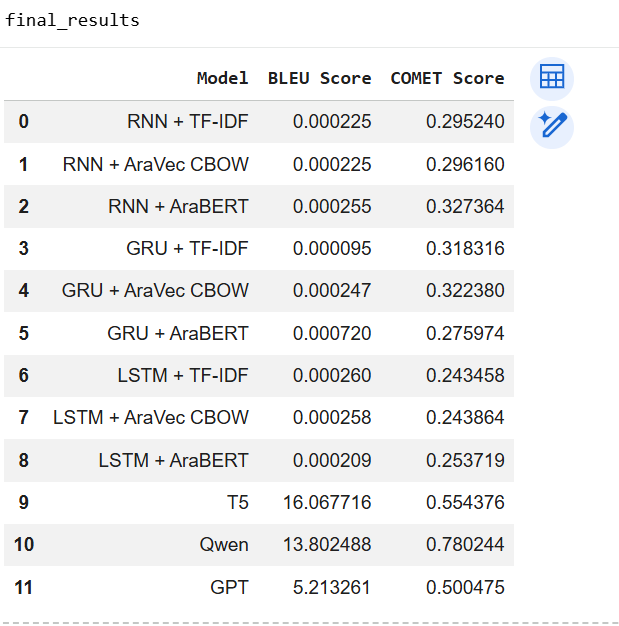

## 8. Selected Model and Export

In [115]:
#qwen was the best model for question answering based on comet

qwen_model.save_pretrained("best_qa_qwen")
qwen_tokenizer.save_pretrained("best_qa_qwen")


('best_qa_qwen/tokenizer_config.json',
 'best_qa_qwen/chat_template.jinja',
 'best_qa_qwen/tokenizer.json')

In [116]:
!zip -r best_qa_qwen.zip best_qa_qwen

  adding: best_qa_qwen/ (stored 0%)
  adding: best_qa_qwen/tokenizer.json (deflated 81%)
  adding: best_qa_qwen/tokenizer_config.json (deflated 60%)
  adding: best_qa_qwen/adapter_model.safetensors (deflated 8%)
  adding: best_qa_qwen/README.md (deflated 65%)
  adding: best_qa_qwen/chat_template.jinja (deflated 71%)
  adding: best_qa_qwen/adapter_config.json (deflated 58%)


In [117]:
merged_model = qwen_model.merge_and_unload()

merged_model.save_pretrained("best_qa_qwen_merged")
qwen_tokenizer.save_pretrained("best_qa_qwen_merged")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('best_qa_qwen_merged/tokenizer_config.json',
 'best_qa_qwen_merged/chat_template.jinja',
 'best_qa_qwen_merged/tokenizer.json')

In [118]:
!zip -r best_qa_qwen_merged.zip best_qa_qwen_merged

  adding: best_qa_qwen_merged/ (stored 0%)
  adding: best_qa_qwen_merged/tokenizer.json (deflated 81%)
  adding: best_qa_qwen_merged/generation_config.json (deflated 39%)
  adding: best_qa_qwen_merged/tokenizer_config.json (deflated 60%)
  adding: best_qa_qwen_merged/model.safetensors (deflated 21%)
  adding: best_qa_qwen_merged/chat_template.jinja (deflated 71%)
  adding: best_qa_qwen_merged/config.json (deflated 71%)
